In [1]:
import pickle
import sys
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pynq import Overlay, allocate
from model_training.load_weights import WeightLoader, decode_output

BIT_FILE    = "cnn_accel.bit"
WEIGHT_DIR  = "model_training/weights"
DMA_NAME    = "axi_dma_0"
 
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

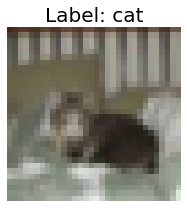

In [14]:
IMAGE_INDEX = 150

batch_path = "dataset/cifar-10-batches-py/data_batch_1"
with open(batch_path, "rb") as f:
    d = pickle.load(f, encoding="bytes")
 
with open("dataset/cifar-10-batches-py/batches.meta", "rb") as f:
    meta = pickle.load(f, encoding="bytes")
classes = [c.decode("utf-8") for c in meta[b"label_names"]]
 
images = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)
labels = d[b"labels"]
 
image = images[IMAGE_INDEX]
true_label = classes[labels[IMAGE_INDEX]]
 
plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.title(f"Label: {true_label}", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
ol  = Overlay(BIT_FILE)
dma = getattr(ol, DMA_NAME)

loader = WeightLoader(WEIGHT_DIR, dma, ol.kernel_0)
loader.preload()

Pre-loading weight files…
  layer1_conv.bin: 128 packets cached
  layer2_conv.bin: 2,944 packets cached
  layer3_conv.bin: 11,264 packets cached
  layer4_conv.bin: 44,544 packets cached
  layer5_mlp.bin: 39,424 packets cached
  layer6_mlp.bin: 5,120 packets cached
  layer7_mlp.bin: 110 packets cached


In [15]:
recv_buf = allocate(shape=(5,), dtype=np.uint32)

t0 = time.time()
probs = loader.run_inference(image, recv_buf)
dt = (time.time() - t0) * 1000

print(f"\nInference time: {dt:.1f} ms")
print(f"\nRaw output words: {[hex(int(recv_buf[i])) for i in range(5)]}")
print(f"\nProbabilities:")
for i, (cls, p) in enumerate(zip(CLASSES, probs)):
    bar = "█" * int(p * 40)
    print(f"  {i:2d}  {cls:<12}  {p:.4f}  {bar}")
print(f"\nPredicted class: {CLASSES[np.argmax(probs)]}")
print(f"Prob sum: {probs.sum():.4f}  (should be ~1.0)")

del recv_buf


Inference time: 7146.5 ms

Raw output words: ['0x17f5195d', '0x1ae11bb1', '0x19be19a3', '0x18fd1795', '0x1ae11942']

Probabilities:
   0  airplane      0.0936  ███
   1  automobile    0.0991  ███
   2  bird          0.1050  ████
   3  cat           0.1082  ████
   4  deer          0.1006  ████
   5  dog           0.1001  ████
   6  frog          0.0976  ███
   7  horse         0.0921  ███
   8  ship          0.1050  ████
   9  truck         0.0987  ███

Predicted class: cat
Prob sum: 0.9999  (should be ~1.0)


In [ ]:
# DO NOT RUN UNTIL COMPLETLY DONE
ol.free()